# Exploration de données clients - Sell4All

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Lecture et Affichage des informations sur les 5 premières lignes du fichier CSV

In [2]:
df=pd.read_csv('dataset-sell4all.csv')

In [3]:
df.head()

,Name,Phone Number,Email,Address,Country,Postal code,Last date of connection,Last time of connection,Age,Gender,Customer spendings
0,Aaron Cote,966-7625,elit@hotmail.org,699-5837 Risus Street,Norway,4126,5-Apr-21,4:39,71,Man,356
1,Angelica Lawson,232-3051,diam.proin@google.org,481-8428 Magna. Street,Pakistan,518885,"oct. 10, 2021",0:36,37,Women,173
2,Louis Gilbert,1-997-733-0134,lorem.fringilla@hotmail.org,Ap #192-2082 Enim. Ave,Colombia,575444,2-Jul-22,3:37,24,Women,105
3,Basia Finley,1-987-322-7148,tristique.aliquet@icloud.co,608-2732 Nec Rd.,South Africa,5973-5765,19-Feb-22,2:34,37,Women,28
4,Rhona Sears,387-7682,iaculis.odio.nam@protonmail.org,8763 In Rd.,France,37476,31-Mar-22,6:28,42,Women,13


## 3. Résumé technique des données

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Name                     505 non-null    str  
 1   Phone Number             505 non-null    str  
 2   Email                    505 non-null    str  
 3   Address                  505 non-null    str  
 4   Country                  505 non-null    str  
 5   Postal code              505 non-null    str  
 6   Last date of connection  505 non-null    str  
 7   Last time of connection  505 non-null    str  
 8   Age                      505 non-null    int64
 9   Gender                   505 non-null    str  
 10  Customer spendings       505 non-null    int64
dtypes: int64(2), str(9)
memory usage: 43.5 KB


### Explication du résumé technique

La méthode **.info()** donne un aperçu technique des données :

● **Combien y a-t-il d'entrées dans l'ensemble de données ?**
  L'ensemble de données contient **505 entrées**, c'est-à-dire 505 clients, indexées de 0 à 504.

● **Qu'est-ce que « non-null »?**
  Non-null indique le nombre de valeurs **renseignées** (non manquantes) pour chaque colonne. Ici, toutes les colonnes affichent **505 non-null**, donc **aucune valeur n'est manquante** dans l'ensemble de données.

● **Quels types de données sont présents ? Quels sont ces types ?**
  On voit deux types principaux, **str** qui représente du texte ou du chaîne de caractères, et **int64** qui représente des nombres entier.

Ce résumé permet de vérifier rapidement la qualité globale des données (absence de valeurs manquantes) et de confirmer que les colonnes numériques **Age**, **Customer spendings** sont bien typées en entier


## 4. Moyenne et médiane

### 4.1 Moyenne et médiane de l'age

In [5]:
age_moy = df['Age'].mean()
age_mediane = df['Age'].median()

print('moyenne age :', round(age_moy,2))
print('mediane age :', age_mediane)

moyenne age : 46.08
mediane age : 46.0


### 4.2 Moyenne et médiane des dépenses clients

In [6]:
print('moyenne Customer spendings :', round(df['Customer spendings'].mean(),2))
print('mediane Customer spendings :', df['Customer spendings'].median())

moyenne Customer spendings : 311.17
mediane Customer spendings : 307.0


On constate que la moyenne et la médiane de l'âge sont assez proches, ce qui montre une distribution homogène des âges. Pour les dépenses, on voit un écart plus marqué entre moyenne et médiane, ce qui indique que quelques clients dépensent beaucoup plus que les autres.

## Question bonus

## 5. Médiane d'age par pays

In [7]:
age_median_pay = df.groupby('Country')['Age'].median().sort_values(ascending=False)

print(age_median_pay)

Country
Turkey                60.0
France                56.5
Spain                 54.5
Norway                54.0
Germany               53.0
Philippines           51.0
Brazil                49.5
South Korea           49.5
Poland                49.5
Ireland               49.0
United States         48.5
United Kingdom        48.5
Netherlands           48.0
Vietnam               48.0
Costa Rica            48.0
Russian Federation    48.0
Mexico                47.0
Ukraine               46.0
Canada                46.0
Chile                 46.0
India                 45.5
Australia             44.0
Pakistan              44.0
South Africa          43.0
Austria               43.0
Singapore             41.5
Indonesia             41.5
Italy                 41.0
Sweden                40.0
Belgium               39.0
New Zealand           38.0
Peru                  38.0
Nigeria               37.0
China                 35.0
Colombia              29.0
Name: Age, dtype: float64


## 6. Visualisation - Dépenses des clients par pays

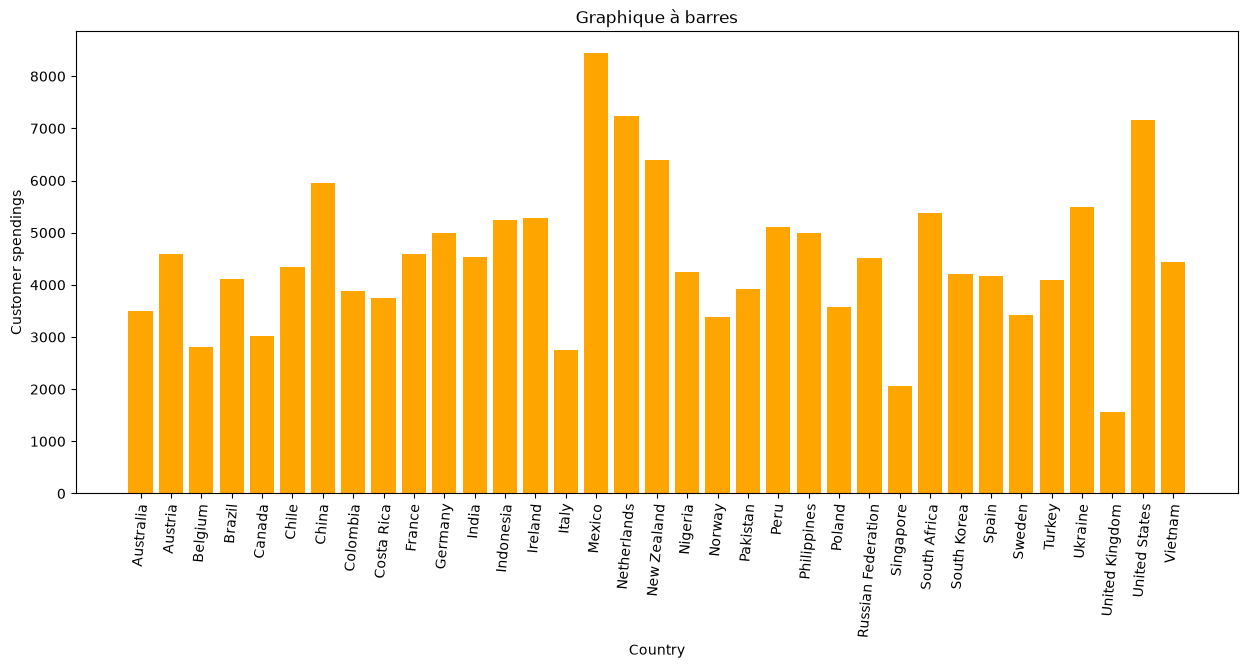

In [8]:
spendings_by_country = df.groupby('Country')['Customer spendings'].sum()

plt.figure(figsize=(15, 6))
plt.bar(spendings_by_country.index, spendings_by_country.values, color='orange')

plt.xlabel('Country')
plt.xticks(rotation=85)
plt.ylabel('Customer spendings')
plt.title('Graphique à barres')

plt.show()

Ce graphique à barres montre les dépenses des clients pour chaque pays. Il permet d'identifier rapidement les pays où les clients de Sell4All dépensent le plus.

## 7. Nettoyage des données

### 7.1 Suppression des lignes avec moins de 10 € de dépenses

In [9]:
print("Nombre de lignes avant nettoyage :", df.shape[0])

df_clean = df[df['Customer spendings'] >= 10]

print("Nombre de lignes après suppression des dépenses < 10 € :", df_clean.shape[0])

Nombre de lignes avant nettoyage : 505
Nombre de lignes après suppression des dépenses < 10 € : 502


On supprime toutes les lignes correspondant à des clients ayant dépensé **moins de 10 €**, car ces clients sont considérés comme peu pertinents pour l'analyse (probablement des comptes inactifs).

### 7.2 Suppression des doublons

In [10]:
df_clean = df_clean.drop_duplicates()

print("Nombre de lignes après suppression des doublons :", df_clean.shape[0])

Nombre de lignes après suppression des doublons : 497


On supprime toutes les doublons, afin d'éviter de fausser les futures analyses ou le futur modèle d'IA avec des données redondantes.

## 8. Export des données nettoyées en CSV

In [11]:
columns = ['Country', 'Age', 'Gender', 'Customer spendings']
df_final = df_clean[columns]
df_final.to_csv('dataset-sell4all-clean.csv', index=False)
print(df_final.head())

        Country  Age Gender  Customer spendings
0        Norway   71    Man                 356
1      Pakistan   37  Women                 173
2      Colombia   24  Women                 105
3  South Africa   37  Women                  28
4        France   42  Women                  13
